### Problem Statement

***Problem Statement*** - 
Design and implement a robust generative search system that can accurately extract relevant information and answer questions from diverse insurance policy documents.  

**Why LlamaIndex**
It offers several advantages for building a retrieval-augmented generative question-answering system:

- It supports unstructured and semi-structured data very well because of the different data connectors, thus simplifying the connection between LLM and real-world data formats. For, insurance policy Q&A use case, this aspect of LlamaIndex is useful as the policy documents can be available as webpages, pdf or word documents. Once data is ingested, LlamaIndex builds an index that allows for efficient retrieval and querying of the data.
-  LlamaIndex’s high-level API enables you to build a question-answering (QA) system with just a few lines of code allowing user to ask natural language questions and receive relevant answers from the indexed data.
- Lower-level API allows you to tweak retrival strategies - such as vector similarity search, keyword search etc. This aspect helped us tweak the system to generate reponse that needs granualar details like a specific clause in a policy and it's meaning.

**Overall Solution Architecture**
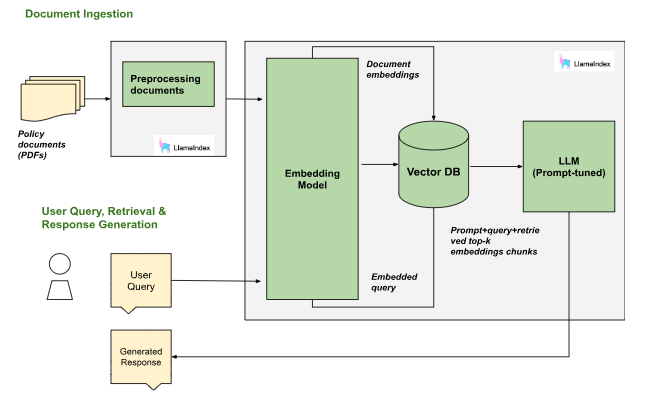

## README 

This repo provides implementation of RAG(Retrieval Augmented generation) using LlamaIndex

**Python Code Breakdown**

1. Setting up libraries

2. Basic Solution PoC using high-level API of LlamaIndex. It has basic structure of data loading, indexing, storing, query engine and response. Enhancements#1 to Enhancement#6 to improve on the basic PoC as observations are made on the response received. 
     - Data source: PDF Docuemnts 

    - Data Loading: SimpleDirectoryReader is used for loading the documents. 

    - Data Pre-processing: Chunking using Nodeparser (Enhnacement #1) to create chunks of size 512 tokens. We enhanced (Enhancement #4) by creating embeddings of the node. This improved the accuracy of responses. 

    - Index Creation : Building an index using VectorStoreIndex from the documents. We also enhanced (Enhancement #2) by using chromadb as vector store. We used ChromaVectorIndex to create index and improved retrieval time. 

    - Query Engine: Setup the query engine such that once the query is passed, the system queries the index and prints the responses. We enhanced (Enhancement #3) to retrive more context for LLM by passing the similarity_top_k=5 argument to the as_query_engine method. This helped create accurate and well informed responses. We also created a response pipeline (Enhancement #5) to allow user to hold conversation with the RAG system. 
    
3. Testing Pipeline: Setup a feedback loop for user testing and collecting good/bad ranking of answers delivered to guage the accuracy of the responses. 

4. Specialized Solution PoC using low-level API. We learnt from the testing pipeline. We enhnaced the data ingestion and retrieval pipeline to generate granular responses that are accurate with reference to source file and page number. We used PromptTemplate and ChatEngine to ground the chatbot to the context and the uploaded documents only. 

    - Used Pdf plumber to extract both regular and tabular text as text chunks
    - Created a dataframe containing the text chunk and meta data like page number, document title etc
    - Generated and stored using the dataframe using OpenAI and ChromaDB
    - Setup semantic search pipeline using distance to find similarity. 

    - Used prompt templates to ground chatbot to queries around HDFC insurance policy only. We also noticed that the chatbot could suggest a policy name that was not part of the document folder. 
    - Used ChatEngine to handle the conversation instead of directly accessing Q&A function of query engine. This gives more control on the responses generated by the RAG system.



**To Run**

- In the setting up section, place your docs in a folder and point the path to "pdf path" to converse with the system.

- In the setting up section, pass your open ai key in variable my_api_key

- In the testing section, initialize_conv(): Initialize a simplistic chatbot that has conversation with the user. The function continuously prompts the user for input, processes the input using the query_response function, and displays the response. The loop terminates when the user types 'exit'.










### Setting Up
1. We will install the LlamaIndex and Openai libraries
2. Import required files for loading, indexing, storing, querying and evaluation from it
3. Setting up the OpenAI API key

In [39]:
# Install OpenAI, LlamaIndex
!pip install llama_index


In [25]:

# Set your OpenAI API key
my_api_key = 'sk-proj-PiekwpWfEbKF5avhdj1eT3BlbkFJ8G8cctq9qBoi126ESNMo'


In [9]:
import os
os.environ["OPENAI_API_KEY"] = my_api_key

In [10]:
# The nest_asyncio module enables the nesting of asynchronous functions within an already running async loop.
# This is necessary because Jupyter notebooks inherently operate in an asynchronous loop.
# By applying nest_asyncio, we can run additional async functions within this existing loop without conflicts.

import nest_asyncio
nest_asyncio.apply()

from llama_index.llms.openai import OpenAI
from IPython.display import display, HTML #managing response pipeline


import os
import pandas as pd



#### Basic Solution POC

In [11]:
#basic code to use LlamaIndex 
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader

pdf_path = "C:\\Users\\writi\\Downloads\\Policy Documents"

documents = SimpleDirectoryReader(input_dir=pdf_path).load_data()
vector_index = VectorStoreIndex.from_documents(documents)
query_engine = vector_index.as_query_engine()
response = query_engine.query("What is the HDFC policy name for young females?")
print(response)

HDFC policy name for young females is HDFC Life Sampoorna Jeevan.


#### Enhancement 1: Parsing documents into smaller chunks

Create nodes from the documents using the node_parser with chunk size of 512.
Rebuilding the index using the nodes instead of the documents. 

In [12]:
# Global settings
from llama_index.core import Settings

Settings.chunk_size = 512

# Chunking 
from llama_index.core.node_parser import SimpleNodeParser
node_parser = SimpleNodeParser.from_defaults(chunk_size=512)
nodes = node_parser.get_nodes_from_documents(documents)

#checking number of nodes extracted
print(f"Number of nodes extracted: {len(nodes)}")

# Roughly checking the content captured by the nodes
first_node = nodes[0]  # Assuming nodes is a list of nodes
content = first_node.text
print(f"Node ID {first_node.node_id}: Content: {content[:50]}...")



Number of nodes extracted: 500
Node ID ab27a5ec-5738-4fbf-bfda-cbf0af3e864d: Content: Part A 
<<Date>> 
<<Policyholder’s Name>>  
<<Poli...


In [15]:
#Rebuilding index
vector_index = VectorStoreIndex(nodes)
query_engine = vector_index.as_query_engine()
response = query_engine.query("Give a name and brief summary of a policy suitable for young girls?")
print(response)

A brief summary of an HDFC policy suitable for young females would be that the policy offers the option for alterations in the frequency of premium payment and income payout frequency. It allows for policy loans during the policy term, with the loan amount being up to 80% of the surrender value. The policy also includes a provision for free look cancellation within a specified period if the policyholder is not agreeable to any of the policy provisions. Additionally, the policy is governed by Indian laws and provides instructions for communication with the company regarding any changes in address.


**Observations**
The answer is vague. The user writing this query would be expecting name and details of the policy suitable for young girls. The details should include information that is meaningful, accurate and precise. We need to refine data ingestion, indexing and retrieval pipeline.

#### Enhancement 2: Using Chromadb as the vector store

- Initializing a connection to chroma database
- Creating a new collection within chroma database
- Setting up a chromavector store using created collection
- Storage context confifgured with ChromaVectorStore for efficient storage and retrieval
- Reconstructing VectorStoreIndex using the parsed nodes and configured storage

This will help us set up a even more efficient retrieval system that can search through smaller chunks of text nodes. 

In [16]:
pip install llama-index-vector-stores-chroma

In [18]:


import chromadb
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import StorageContext

chroma_client = chromadb.PersistentClient()
chroma_collection = chroma_client.create_collection("RAG_Insurance")
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

In [21]:
#reproducing the index using both nodes and storage context
vector_index = VectorStoreIndex(
    nodes, storage_context=storage_context
)
query_engine = vector_index.as_query_engine()

Insert of existing embedding ID: ab27a5ec-5738-4fbf-bfda-cbf0af3e864d
Insert of existing embedding ID: 2bf5252c-fd89-4b74-abea-775dbdc9a47a
Insert of existing embedding ID: 990abbc5-a1b4-44f3-893c-507daf4951c3
Insert of existing embedding ID: 4e7926a2-d3ab-4d10-91fe-e27f9fe3db3b
Insert of existing embedding ID: 7fc40b3d-6971-41cf-8675-04cb146d2e36
Insert of existing embedding ID: d980c7ec-67e1-4dc8-b1ad-eccfd1e64432
Insert of existing embedding ID: 2acac10f-e495-4a54-96ed-3bb136e0ab33
Insert of existing embedding ID: 709c8a2f-dd83-45ef-b3cb-75cf99a3392e
Insert of existing embedding ID: b84488ca-f49c-47b8-b6db-c0d979b9975f
Insert of existing embedding ID: 146ed1aa-15cd-4845-9cd9-c2ea4c8508e8
Insert of existing embedding ID: 35be89b4-a85c-400d-9675-c484539b05ec
Insert of existing embedding ID: 0858b7b9-a9ca-40ee-a26f-4bef8a500357
Insert of existing embedding ID: 75d02130-ae00-46d3-8ad0-cffc9c13d2dc
Insert of existing embedding ID: 41f3837e-11b2-4b5f-a51a-8dce7afa4583
Insert of existing e

Insert of existing embedding ID: 95b6ccb0-9776-4624-8f60-25b7fc4bc133
Insert of existing embedding ID: f4bbcbc1-aefb-4d0b-bd55-a6f6e8a1664f
Insert of existing embedding ID: 36239bde-65c5-4581-ba6a-70e22b807480
Insert of existing embedding ID: 9291c9fd-4100-46f0-8b8a-5f34f5be4c29
Insert of existing embedding ID: 2a8a278b-3a1c-4f52-9fff-5f073e4deef0
Insert of existing embedding ID: 17cbc868-b1bf-4db3-bee8-4666299071aa
Insert of existing embedding ID: 85dee2ee-35d9-4fcb-acfc-ea2659237c5f
Insert of existing embedding ID: de00c4da-a186-4ece-a621-d8559fec22ac
Insert of existing embedding ID: 9d8be9fb-1033-4f7c-8f9b-883730a2cb4a
Insert of existing embedding ID: 3a4c087a-253d-4ba9-9fbb-0f89431b79da
Insert of existing embedding ID: b00446f4-0be4-4ec8-86f8-24878837aca8
Insert of existing embedding ID: a39e9344-5861-4aa9-99ce-6e813ba86803
Insert of existing embedding ID: a58f3b02-414a-4340-b07d-38ae726a7dc3
Insert of existing embedding ID: 450c224a-2fc2-4baf-8256-3e4a9f9530ad
Insert of existing e

Insert of existing embedding ID: 7529f039-069e-4454-8cd3-78035ba1cf64
Insert of existing embedding ID: e5d7871f-6447-4e2a-bf8b-d3f6d8e604e1
Insert of existing embedding ID: 9cc3b482-28f0-495e-a68f-7e8a52b18f6e
Insert of existing embedding ID: 886e452a-1e87-4560-a506-8683bfed37c6
Insert of existing embedding ID: 37ab8db3-e429-4f95-86e5-b800156c616e
Insert of existing embedding ID: d8174b1b-7cf2-428e-9498-6478ec8c8395
Insert of existing embedding ID: 53bf789d-0755-4274-ba4c-222928756638
Insert of existing embedding ID: f642c346-25ca-43df-b7ce-5c08c540d12a
Insert of existing embedding ID: fd5556a0-6c3f-4974-8ff5-0db6bd79964b
Insert of existing embedding ID: e2915f19-13ba-452a-b026-d92347f25fa5
Insert of existing embedding ID: 6c70b2fe-6460-4ee2-9188-0c80ed869649
Insert of existing embedding ID: be23209a-1c0e-42ad-b22f-b3262f52e542
Insert of existing embedding ID: d1326f06-1997-4201-b848-e8f9891525b6
Insert of existing embedding ID: 7efb58f7-800a-4430-adbc-25085657b8d5
Insert of existing e

Insert of existing embedding ID: c4133279-d394-4f04-a2f5-2987134164c3
Insert of existing embedding ID: 71f2900b-2e58-41c5-850f-98296a7e9e2b
Insert of existing embedding ID: c4d48fc6-0de0-47e6-9bff-c8a94d031cb1
Insert of existing embedding ID: da749194-c0d1-4bf0-b204-526eb7ba0e84
Insert of existing embedding ID: d55e3d44-b4de-4537-bc23-53f84dcaa360
Insert of existing embedding ID: 3f183386-912f-42ba-8af4-9b47f9fb1cf0
Insert of existing embedding ID: 33bb13d6-8d3d-4aab-80d9-9741ef4bb305
Insert of existing embedding ID: de1c7050-fa6e-4797-9fd5-2de827b3e406
Insert of existing embedding ID: ba432cfb-05b1-4b87-93e8-ba641cddbd39
Insert of existing embedding ID: c6c627ca-7d8b-442d-96fa-8eb1a28186d6
Insert of existing embedding ID: 879e76cf-47ab-4b8e-a466-af1871357888
Insert of existing embedding ID: 4fdcdff0-6443-40a9-a4db-7a7b19bed72e
Insert of existing embedding ID: ef70dc1a-0895-4d5e-ab19-c1bf59928124
Insert of existing embedding ID: 51eccb61-fa6f-489b-b338-f5eee1af1b36
Insert of existing e

Insert of existing embedding ID: 0fdf87a8-0608-43a3-babe-e78d8b48a875
Insert of existing embedding ID: f8e5019a-9537-4110-8685-61bd54203848
Insert of existing embedding ID: 099eed44-ce1f-4aa6-9c68-5726c0efb577
Insert of existing embedding ID: 3b3df4e6-1a13-4660-b327-ac3d06fa782a
Insert of existing embedding ID: d4638461-c15e-4552-9c51-2f1e1379183d
Insert of existing embedding ID: de8d42a5-fbbb-4e29-922e-b6e5852f9035
Insert of existing embedding ID: 614200dd-4413-4e4a-a56b-0583e55a37a6
Insert of existing embedding ID: fa580733-be83-4d27-bff1-8ba05d106a7c
Insert of existing embedding ID: 2badfefc-0121-4ba0-9448-8383e79096ce
Insert of existing embedding ID: 6c08e450-248f-4ce8-b48e-44a115291b5d
Insert of existing embedding ID: 18e3c0ee-5765-4162-a2d8-43de8668b736
Insert of existing embedding ID: 2b143547-4cb9-46b5-b425-666445607056
Insert of existing embedding ID: 31ad7cae-763b-476f-a98e-07f5fa5db43c
Insert of existing embedding ID: e1e98fd5-82d9-4170-abd5-91f471803bef
Insert of existing e

Add of existing embedding ID: a8dbcec4-e7e1-47a1-b73d-967126397ed2
Add of existing embedding ID: b944c016-f5f8-4928-a281-76f6b881001d
Add of existing embedding ID: 8b081821-e5a0-48ae-a7f6-207a6ea82c3f
Add of existing embedding ID: 331afd62-2c6d-423c-9a87-d86bffbe24ea
Add of existing embedding ID: 7454c905-fba2-4ed3-bfc9-4555b51873c9
Add of existing embedding ID: d824bcef-084d-4614-b70a-17c45e7c0052
Add of existing embedding ID: c7260fcc-6800-4b55-8c7c-b584a1b190bd
Add of existing embedding ID: aaee9b57-7b25-463a-8b96-61caa9d79627
Add of existing embedding ID: dbb18735-7838-4806-8655-ceae8937d4c0
Add of existing embedding ID: 8b65c893-86b0-404a-93ac-81806116dcb0
Add of existing embedding ID: 771af5b9-03ab-4a2c-9826-0fbd73bd1428
Add of existing embedding ID: 710b8dc3-ac37-4d8c-9a68-7f0c3d87d5ab
Add of existing embedding ID: f7d57ad2-940d-4a9d-bb9a-106e4aa19af6
Add of existing embedding ID: d4e09262-4641-49d8-976e-e5885fe3087b
Add of existing embedding ID: de9fef4a-e8bf-46b0-a974-d09d6bab

Add of existing embedding ID: 543c1e78-0268-49fb-93b6-db901fa04e2e
Add of existing embedding ID: 11341704-7657-48bf-aa55-4640f0059604
Add of existing embedding ID: 323540aa-8bf8-420d-afb3-886ec152075d
Add of existing embedding ID: b73a3980-e9a3-46d7-98a2-f9727da5c1c8
Add of existing embedding ID: 3af1e28c-f34c-47ce-85de-31142edb423b
Add of existing embedding ID: 00ea279d-fa3b-47fc-ae85-a669c920fcd1
Add of existing embedding ID: 2ff62277-83a4-4677-a9a2-1247c939ceb5
Add of existing embedding ID: b15ca365-6a61-403e-899a-760d8d10c488
Add of existing embedding ID: 940cacf8-f482-4e72-907f-fdf074b69424
Add of existing embedding ID: 3f6522e4-4a77-462c-8d4d-9ccf930cd0d7
Add of existing embedding ID: 165b0faa-f9c1-4114-bc03-bcc3cb41198c
Add of existing embedding ID: 811c2a95-c3dd-4677-9db9-0468730524f7
Add of existing embedding ID: a30c8119-8759-4e4c-a420-c48c5bb69896
Add of existing embedding ID: 4ecd53b4-ce5b-4856-9c2e-7f7b8e451461
Add of existing embedding ID: 9c871928-35a6-4326-ba77-5db68b2f

Add of existing embedding ID: ba37b767-9e3e-4a44-8f66-17a68afc42d0
Add of existing embedding ID: 6edc1608-9739-4ad4-862c-8773d73f01bc
Add of existing embedding ID: 3bad34c8-1b31-493d-8e12-7a74c6af3bfa
Add of existing embedding ID: b1888131-b25c-449b-b89c-0c2818ec2e14
Add of existing embedding ID: aeedcc56-095c-41a5-a797-43fefd8d96fc
Add of existing embedding ID: 9a3c876a-76c2-426a-8206-ce295c2f8775
Add of existing embedding ID: 26bb6bc1-cc14-4eee-b569-37b010dda12b
Add of existing embedding ID: 06fdecdd-d03b-4719-a7e9-aae238b5d960
Add of existing embedding ID: 09d15fe4-7547-47fb-b858-9f6fb1c4b94c
Add of existing embedding ID: 60bdb6b4-bef1-4107-b928-038540c7459d
Add of existing embedding ID: 1787eaba-9bec-47a3-8926-83db76ce2a8f
Add of existing embedding ID: 270ebf06-e82b-443f-9b17-c7fe3dee687d
Add of existing embedding ID: e1f24bbc-6d50-48bf-a761-d90379779b69
Add of existing embedding ID: 210a0401-3e18-46f0-ae17-5a4d4d1fc6cc
Add of existing embedding ID: c4133279-d394-4f04-a2f5-29871341

Add of existing embedding ID: a5ea5aed-08be-4d9f-b443-003692b3dafb
Add of existing embedding ID: 4520da1b-b675-43d6-bc7a-2eade38a4405
Add of existing embedding ID: 7a2acaa7-1c8a-4249-b66e-42d3009088fe
Add of existing embedding ID: 4f6dc0d6-836a-4981-b533-181f45de1daf
Add of existing embedding ID: 1e7651b4-466c-4627-a03c-e55555d7f651
Add of existing embedding ID: cac585d5-91b0-4d29-a295-d211996bc20c
Add of existing embedding ID: dc372407-d5d7-4ff8-a1b8-dbe463080a45
Add of existing embedding ID: ce802e4b-50f8-4a22-b4ea-ea2107f83ec6
Add of existing embedding ID: 960ef8f3-2de4-4cb7-80b5-66d35e5096b9
Add of existing embedding ID: 0fdf87a8-0608-43a3-babe-e78d8b48a875
Add of existing embedding ID: f8e5019a-9537-4110-8685-61bd54203848
Add of existing embedding ID: 099eed44-ce1f-4aa6-9c68-5726c0efb577
Add of existing embedding ID: 3b3df4e6-1a13-4660-b327-ac3d06fa782a
Add of existing embedding ID: d4638461-c15e-4552-9c51-2f1e1379183d
Add of existing embedding ID: de8d42a5-fbbb-4e29-922e-b6e5852f

In [23]:
response = query_engine.query("What is the name of the policy which is suitable for young girls?")
print(response)

HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay


**Observations**
The answers have become precise, since use of chromadb helps for better indexing and retrieval.
There are better contenders in the list of policy documents, but it seems the query engine retrived the first relevant document/chunk. We should increase the context of the querying engine

#### Enhancement 3: Retrieving more context when querying

By passing the similarity_top_k=5 argument to the as_query_engine method, we configured the default retriever to return the top 5 most similar documents (instead of the default 2)

In [24]:
# Rebuilding the query engine with new similarity argument

query_engine = vector_index.as_query_engine(similarity_top_k=5)
response = query_engine.query("What is the name of the policy which is suitable for young girls?")
print(response)

HDFC Life Sampoorna Jeevan Plan


**Observation**
This definitely made the answer precise and accurate.

#### Enhancement 4: Introducing embeddings  

In [27]:
# Import necessary modules from LlamaIndex
from llama_index.embeddings.openai import OpenAIEmbedding


#Now passing the embedding function to the chroma collection
chroma_collection = chroma_client.create_collection("RAG_Insurance_modified")
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

In [31]:
#reproducing the index using embedding function, nodes and storage context

embed_model = OpenAIEmbedding()

vector_index = VectorStoreIndex(
    nodes, storage_context=storage_context, embed_model=embed_model)
query_engine = vector_index.as_query_engine(similarity_top_k=5)

In [32]:
response = query_engine.query("What is the name and details of a policy suitable for young girls?")
print(response)

The policy suitable for young girls is the HDFC Life Sampoorna Jeevan Plan. It is a Non-Linked, Participating Individual Life Insurance Savings Product offered by HDFC Life Insurance Company Limited. The policy provides a death benefit for minor life assured individuals, with specific conditions based on the age of the life assured. It is important to note that the policy does not indicate the quality of the product, its future prospects, or returns.


**Observations**
The answer is precise, accurate and right description has been extracted to give more details on the policy. Now we would want to turn into a chat experience where the user can ask multiple questions.

#### Enhancement 5: Creating an interactive chatbot

Modifying the functions `query_response` functions return the query response from the query engine and `initialize_conv()` function creates an interactive chatbot.

In [33]:
## Query response function
def query_response(user_input):
    """
    Generate a response based on user input by querying the query engine and
    retrieving metadata from the source nodes.

    Args:
    user_input (str): The input query provided by the user.

    Returns:
    final_response (str): The final response generated by the query engine
    """
    response = query_engine.query(user_input)
    return response

In [34]:
def initialize_conv():
    """
    Initialize a conversation with the user, allowing them to ask questions
    about the policy documents. The user can type 'exit' to end the
    conversation.
    """
    print('Feel free to ask questions about insurance policies offered by HDFC?')
    while True:
        user_input = input()
        # Type 'exit' to exit conversation
        if user_input.lower() == 'exit':
            print('Exiting the conversation... bye')
            break
        else:
            response = query_response(user_input)
            display(HTML(f'<p style="font-size:20px">{response}</p>'))


### Testing

In [ ]:
#Testing the interactive chat
initialize_conv()

Feel free to ask questions about insurance policies offered by HDFC?


In [130]:
#Testing Part 2

initialize_conv()

Feel free to ask questions about insurance policies offered by HDFC?
How many policies can you help me with?


what are the names of these policies?


Is there not a policy named sampoorna?


exit
Exiting the conversation... bye


In [134]:
#Testing part 3
initialize_conv()

Feel free to ask questions about insurance policies offered by HDFC?
ca  you tell me a health insurance policy by hdfc


can i ask you about anything apart than hdfc


exit
Exiting the conversation... bye


**Observations**
The answers are precise, accurate and right description has been extracted to give more details on the policy. Now here is room for more improvements

- Some of the legal language might feel obtusive, for example, "....this policy provides a death benefit for minor life....".
- The conversing agent deviated from answering out of the limited scope of insurance policy documents.

We can setup a system that will help us get these feedbacks from the user testing phase. 



#### Creating a Testing Pipeline

Here we feed a series of questions to the Q/A bot and store the responses along with the feedback on whether it's accurate or not from the user

Create atleast 5 questions and store them in the `questions` list to be queried by the RAG system using the `testing_pipeline` function.

In [36]:
questions = ['What critical illnesses are covered under this policy?','What is the address for correspondence with HDFC Life Insurance Company Limited?', 'What is the duration of the free-look period and what are the conditions?', 'What are the premium payment terms and frequency?','What events are covered under this policy?' ]

In [132]:

def get_user_feedback():
    """
    Prompt the user for feedback and return their response.

    Returns:
        str: User feedback (either "good" or "bad").
    """
    user_input = input("Was the response good or bad? (Type 'good' or 'bad'): ")
    return user_input.lower()  # Convert to lowercase for consistency

def testing_pipeline(questions):
    """
    Conduct a testing pipeline for a series of questions, collecting user
    feedback on the responses provided by the bot.

    Args:
        questions (list): A list of questions to be tested.

    Returns:
        pd.DataFrame: A DataFrame containing the questions, their corresponding
        responses, the page number from the response, and the user feedback
        indicating whether the response was good or bad.
    """
    # Placeholder logic: Replace with actual implementation
    responses = []
    for question in questions:
        # Query the bot for a response based on the question
        response = query_response(question)
        

        #Collect user feedback (good or bad)
        print(question)
        print(response)
        user_feedback = get_user_feedback()

        # Append the results to the list
        responses.append({
            "Question": question,
            "Response": response,
            "User Feedback": user_feedback
        })

    # Create a DataFrame from the collected responses
    feedback_df = pd.DataFrame(responses)

    return feedback_df



In [133]:
test_results=testing_pipeline(questions)
print(test_results)

What critical illnesses are covered under this policy?
The critical illnesses covered under this policy are:
1. Myocardial Infarction (First Heart Attack of specific severity)
2. Open Heart Replacement or Repair of Heart Valves
3. Cancer of Specified Severity
4. Kidney failure requiring regular dialysis
5. Stroke resulting in permanent symptoms
6. Alzheimer's Disease
7. Apallic Syndrome
8. Coma of specified severity
9. End Stage Liver Failure
10. End Stage Lung Failure
11. Loss of Independent Existence
12. Blindness
13. Third Degree Burns
14. Major Head Trauma
15. Parkinson's Disease
16. Permanent paralysis of limbs
17. Multiple Sclerosis with persisting symptoms
Was the response good or bad? (Type 'good' or 'bad'): good
What is the address for correspondence with HDFC Life Insurance Company Limited?
The address for correspondence with HDFC Life Insurance Company Limited is 11th Floor Lodha Excelus, Apollo Mills Compound, N.M. Joshi Marg, Mahalaxmi, Mumbai-400011.
Was the response good

### Specialized Solution PoC

The responses of testing pipelines are good but we can do more to improve RAG performance that could provide information. For example, price, age ranges etc. that are usually present in a pdf table. We can also also build metadata like - the page number and policy document name for the retrieved chunks. This improves the user experience of interactive chats.

- Using a specialized data connector pdf plumber to extract both regular and tabular text from the pdfs
- Extracting meta data like page number, document name for  giving source in the response

Another observation, that the chatbot started answering beyond HDFC policy documents. This could be improved by providing custom prompt template 



**Using PdfPlumber to extract text**


In [37]:
pip install pdfplumber


Note: you may need to restart the kernel to use updated packages.


In [38]:
#importing libraries

from pathlib import Path
import pdfplumber
from operator import itemgetter
import json


In [39]:
# Function to check whether a word is present in a table or not for segregation of regular text and tables

def check_bboxes(word, table_bbox):
    # Check whether word is inside a table bbox.
    l = word['x0'], word['top'], word['x1'], word['bottom']
    r = table_bbox
    return l[0] > r[0] and l[1] > r[1] and l[2] < r[2] and l[3] < r[3]

 These are steps this function would complete: 
- Declare a variable p to store the iteration of the loop that will help us store page numbers alongside the text
- Declare an empty list 'full_text' to store all the text files
- Use pdfplumber that opens pdf pages one by one
- Find the tables and their locations in the page
- Extract the tabular text in the variable 'tables'
- Extract the regular words by calling the function check_bboxes() and checking whether words are present in the table or not
- Use the cluster_objects utility to cluster non-table and table words together so that they retain the same chronology as in the original PDF
- Declare an empty list 'lines' to store the page text
- If a text element in present in the cluster, append it to 'lines', else if a table element is present, append the table
- Append the page number and all lines to full_text, and increment 'p'
- When the function has iterated over all pages, return the 'full_text' list

In [42]:
# Function to extract text from a PDF file and save page number, document name etc. 

def extract_text_from_pdf(pdf_path):
    p = 0
    full_text = []


    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_no = f"Page {p+1}"
            text = page.extract_text()

            tables = page.find_tables()
            table_bboxes = [i.bbox for i in tables]
            tables = [{'table': i.extract(), 'top': i.bbox[1]} for i in tables]
            non_table_words = [word for word in page.extract_words() if not any(
                [check_bboxes(word, table_bbox) for table_bbox in table_bboxes])]
            lines = []

            for cluster in pdfplumber.utils.cluster_objects(non_table_words + tables, itemgetter('top'), tolerance=5):

                if 'text' in cluster[0]:
                    try:
                        lines.append(' '.join([i['text'] for i in cluster]))
                    except KeyError:
                        pass

                elif 'table' in cluster[0]:
                    lines.append(json.dumps(cluster[0]['table']))


            full_text.append([page_no, " ".join(lines)])
            p +=1

    return full_text

In [43]:
# Define the directory containing the PDF files
pdf_directory = Path(pdf_path)

# Initialize an empty list to store the extracted texts and document names
data = []

# Loop through all files in the directory
for pdf_path in pdf_directory.glob("*.pdf"):

    # Process the PDF file
    print(f"...Processing {pdf_path.name}")

    # Call the function to extract the text from the PDF
    extracted_text = extract_text_from_pdf(pdf_path)

    # Convert the extracted list to a PDF, and add a column to store document names
    extracted_text_df = pd.DataFrame(extracted_text, columns=['Page No.', 'Page_Text'])
    extracted_text_df['Document Name'] = pdf_path.name

    # Append the extracted text and document name to the list
    data.append(extracted_text_df)

    # Print a message to indicate progress
    print(f"Finished processing {pdf_path.name}")

# Print a message to indicate all PDFs have been processed
print("All PDFs have been processed.")

...Processing HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
Finished processing HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf
...Processing HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf
Finished processing HDFC-Life-Group-Poorna-Suraksha-101N137V02-Policy-Document.pdf
...Processing HDFC-Life-Group-Term-Life-Policy.pdf
Finished processing HDFC-Life-Group-Term-Life-Policy.pdf
...Processing HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-Document (1).pdf
Finished processing HDFC-Life-Sampoorna-Jeevan-101N158V04-Policy-Document (1).pdf
...Processing HDFC-Life-Sanchay-Plus-Life-Long-Income-Option-101N134V19-Policy-Document.pdf
Finished processing HDFC-Life-Sanchay-Plus-Life-Long-Income-Option-101N134V19-Policy-Document.pdf
...Processing HDFC-Life-Smart-Pension-Plan-Policy-Document-Online.pdf
Finished processing HDFC-Life-Smart-Pension-Plan-Policy-Document-Online.pdf
...Processing HDFC-Surgicare-Plan-101N043V01.pdf
Finished processing HDFC-Surgicare-

In [44]:
# Concatenate all the DFs in the list 'data' together

documents_df = pd.concat(data, ignore_index=True)

In [45]:
#checking the dataframe
documents_df.head()

,Page No.,Page_Text,Document Name
0,Page 1,Part A <<Date>> <<Policyholder’s Name>> <<Poli...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...
1,Page 2,Agency/Intermediary Contact Details: <<Agency/...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...
2,Page 3,POLICY DOCUMENT- HDFC LIFE EASY HEALTH Unique ...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...
3,Page 4,"[[null, ""<< dd/mm/yyyy >>""], [""Appointee's Add...",HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...
4,Page 5,Part B Definitions The following capitalised t...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...


In [46]:
# Let's also check the length of all the texts as there might be some empty pages or pages with very few words that we can drop

documents_df['Text_Length'] = documents_df['Page_Text'].apply(lambda x: len(x.split(' ')))

In [47]:
# Retain only the rows with a text length of at least 10

documents_df = documents_df.loc[documents_df['Text_Length'] >= 10]
documents_df

,Page No.,Page_Text,Document Name,Text_Length
0,Page 1,Part A <<Date>> <<Policyholder’s Name>> <<Poli...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,508
1,Page 2,Agency/Intermediary Contact Details: <<Agency/...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,85
2,Page 3,POLICY DOCUMENT- HDFC LIFE EASY HEALTH Unique ...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,298
3,Page 4,"[[null, ""<< dd/mm/yyyy >>""], [""Appointee's Add...",HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,63
4,Page 5,Part B Definitions The following capitalised t...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,514
...,...,...,...,...
212,Page 11,HDFC Standard Life Insurance Company Limited H...,HDFC-Surgicare-Plan-101N043V01.pdf,316
213,Page 12,HDFC Standard Life Insurance Company Limited H...,HDFC-Surgicare-Plan-101N043V01.pdf,353
214,Page 13,HDFC Standard Life Insurance Company Limited H...,HDFC-Surgicare-Plan-101N043V01.pdf,348
215,Page 14,HDFC Standard Life Insurance Company Limited H...,HDFC-Surgicare-Plan-101N043V01.pdf,496


In [48]:
# Store the metadata for each page in a separate column

documents_df['Metadata'] = documents_df.apply(lambda x: {'Policy_Name': x['Document Name'][:-4], 'Page_No.': x['Page No.']}, axis=1)

In [49]:
# check for the final documents_df
documents_df.head()

,Page No.,Page_Text,Document Name,Text_Length,Metadata
0,Page 1,Part A <<Date>> <<Policyholder’s Name>> <<Poli...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,508,{'Policy_Name': 'HDFC-Life-Easy-Health-101N110...
1,Page 2,Agency/Intermediary Contact Details: <<Agency/...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,85,{'Policy_Name': 'HDFC-Life-Easy-Health-101N110...
2,Page 3,POLICY DOCUMENT- HDFC LIFE EASY HEALTH Unique ...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,298,{'Policy_Name': 'HDFC-Life-Easy-Health-101N110...
3,Page 4,"[[null, ""<< dd/mm/yyyy >>""], [""Appointee's Add...",HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,63,{'Policy_Name': 'HDFC-Life-Easy-Health-101N110...
4,Page 5,Part B Definitions The following capitalised t...,HDFC-Life-Easy-Health-101N110V03-Policy-Bond-S...,514,{'Policy_Name': 'HDFC-Life-Easy-Health-101N110...


**Generating and storing embeddings using OpenAI and chromaDB**

In [51]:
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

# Set up the embedding function using the OpenAI embedding model

model = "text-embedding-ada-002"
embedding_function = OpenAIEmbeddingFunction(api_key=my_api_key, model_name=model)

# Initialise a collection in chroma and pass the embedding_function to it so that it used OpenAI embeddings to embed the documents

insurance_collection = chroma_client.get_or_create_collection(name='RAG_Processed_Insurance_Data', embedding_function=embedding_function)

In [52]:
# Convert the page text and metadata from your dataframe to lists to be able to pass it to chroma

documents_list = documents_df["Page_Text"].tolist()
metadata_list = documents_df['Metadata'].tolist()

In [53]:
# Add the documents and metadata to the collection alongwith generic integer IDs. You can also feed the metadata information as IDs by combining the policy name and page no.

insurance_collection.add(
    documents= documents_list,
    ids = [str(i) for i in range(0, len(documents_list))],
    metadatas = metadata_list
)

In [54]:
# Let's take a look at the first few entries in the collection

insurance_collection.get(
    ids = ['0','1','2'],
    include = ['embeddings', 'documents', 'metadatas']
)

{'ids': ['0', '1', '2'],
 'embeddings': [[0.006250700913369656,
   0.015235254541039467,
   -0.0023456718772649765,
   -0.0409812405705452,
   0.003480353159829974,
   0.045626137405633926,
   0.002977709285914898,
   0.0021200627088546753,
   -0.0209418386220932,
   -0.001512079150415957,
   0.031134065240621567,
   0.015845727175474167,
   -0.004104096442461014,
   0.014638054184615612,
   -0.0033957497216761112,
   0.017783310264348984,
   0.02333064191043377,
   -0.020902026444673538,
   0.025692902505397797,
   -1.564282320032362e-05,
   -0.002292587421834469,
   0.021419599652290344,
   -0.0026127533055841923,
   0.02638300135731697,
   -0.009548576548695564,
   0.0015046141343191266,
   0.02053043432533741,
   -0.006204252131283283,
   -0.0011720064794644713,
   -0.0006444791215471923,
   -0.0035135310608893633,
   0.002781960181891918,
   -0.027657030150294304,
   -0.007133231032639742,
   -0.008838570676743984,
   0.005630275700241327,
   -0.014147021807730198,
   -0.020663145

In [56]:
#calling the collection
cache_collection = chroma_client.get_or_create_collection(name='Insurance_Cache', embedding_function=embedding_function)

In [57]:
# quick inspection of the contents of the collection
cache_collection.peek()

{'ids': ['insurance on house fires'],
 'embeddings': [[-0.004973196424543858,
   -0.0040076919831335545,
   -0.026397239416837692,
   -0.03151949867606163,
   -0.01878160983324051,
   -0.0009019847493618727,
   0.0020377233158797026,
   0.006978736259043217,
   0.014797631651163101,
   0.011233733035624027,
   0.009058806113898754,
   0.027671027928590775,
   0.008936847560107708,
   0.0071684494614601135,
   -0.0008384647080674767,
   0.04219764098525047,
   0.031871821731328964,
   0.011382793076336384,
   0.007385264616459608,
   -0.02002829685807228,
   -0.016898028552532196,
   -0.014784080907702446,
   -0.013957472518086433,
   0.00760885514318943,
   -0.002181702060624957,
   -0.009959944523870945,
   0.010007372125983238,
   -0.01688447780907154,
   0.0016684600850567222,
   0.004149976652115583,
   0.02440525032579899,
   -0.004749605897814035,
   -0.040219202637672424,
   0.0023477012291550636,
   0.006213108077645302,
   0.0076901610009372234,
   -0.008564196527004242,
   0.

**Semantic Search Pipeline**

In [58]:
# Read the user query

query = input()

IS there a policy that would help me insure my house and furniture?


In [59]:
# Searh the Cache collection first
# Query the collection against the user query and return the top 20 results

cache_results = cache_collection.query(
    query_texts=query,
    n_results=1
)

In [60]:
cache_results

{'ids': [['insurance on house fires']],
 'distances': [[0.2445571975845634]],
 'metadatas': [[{'distances0': '0.4507615864276886',
    'distances1': '0.45714277029037476',
    'distances2': '0.45918023586273193',
    'distances3': '0.45977672934532166',
    'distances4': '0.4617922604084015',
    'distances5': '0.46194947615578363',
    'distances6': '0.4642489552497864',
    'distances7': '0.4659481942653656',
    'distances8': '0.46985259652137756',
    'distances9': '0.47154879570007324',
    'documents0': 'thereof, within 15 days from the date of receipt of the Certificate of Insurance, as per IRDAI (Protection of Policyholders’ Interests) Regulations, 2017 (2) In case of the Product is sold through Distance Marketing mode, the period will be 30 days from the date of receipt of the letter along with Certificate of Insurance (3) On receipt of the letter along with the Certificate of Insurance, we shall arrange to refund the premium, subject to deduction of the proportionate risk pre

In [61]:
results = insurance_collection.query(
query_texts=query,
n_results=10
)
# results.items()

In [62]:
# Implementing Cache in Semantic Search

# Set a threshold for cache search
threshold = 0.2

ids = []
documents = []
distances = []
metadatas = []
results_df = pd.DataFrame()


# If the distance is greater than the threshold, then return the results from the main collection.

if cache_results['distances'][0] == [] or cache_results['distances'][0][0] > threshold:
      # Query the collection against the user query and return the top 10 results
      results = insurance_collection.query(
      query_texts=query,
      n_results=10
      )

      # Store the query in cache_collection as document w.r.t to ChromaDB so that it can be embedded and searched against later
      # Store retrieved text, ids, distances and metadatas in cache_collection as metadatas, so that they can be fetched easily if a query indeed matches to a query in cache
      Keys = []
      Values = []

      for key, val in results.items():
        if val is None:
          continue
        for i in range(10):
          Keys.append(str(key)+str(i))
          Values.append(str(val[0][i]))


      cache_collection.add(
          documents= [query],
          ids = [query],  # Or if you want to assign integers as IDs 0,1,2,.., then you can use "len(cache_results['documents'])" as will return the no. of queries currently in the cache and assign the next digit to the new query."
          metadatas = dict(zip(Keys, Values))
      )

      print("Not found in cache. Found in main collection.")

      result_dict = {'Metadatas': results['metadatas'][0], 'Documents': results['documents'][0], 'Distances': results['distances'][0], "IDs":results["ids"][0]}
      results_df = pd.DataFrame.from_dict(result_dict)
      results_df


# If the distance is, however, less than the threshold, you can return the results from cache

elif cache_results['distances'][0][0] <= threshold:
      cache_result_dict = cache_results['metadatas'][0][0]

      # Loop through each inner list and then through the dictionary
      for key, value in cache_result_dict.items():
          if 'ids' in key:
              ids.append(value)
          elif 'documents' in key:
              documents.append(value)
          elif 'distances' in key:
              distances.append(value)
          elif 'metadatas' in key:
              metadatas.append(value)

      print("Found in cache!")

      # Create a DataFrame
      results_df = pd.DataFrame({
        'IDs': ids,
        'Documents': documents,
        'Distances': distances,
        'Metadatas': metadatas
      })


Not found in cache. Found in main collection.


In [63]:
print(results_df)

                                           Metadatas  \
0  {'Page_No.': 'Page 14', 'Policy_Name': 'HDFC-L...   
1  {'Page_No.': 'Page 15', 'Policy_Name': 'HDFC-L...   
2  {'Page_No.': 'Page 26', 'Policy_Name': 'HDFC-L...   
3  {'Page_No.': 'Page 31', 'Policy_Name': 'HDFC-L...   
4  {'Page_No.': 'Page 4', 'Policy_Name': 'HDFC-Li...   
5  {'Page_No.': 'Page 33', 'Policy_Name': 'HDFC-L...   
6  {'Page_No.': 'Page 18', 'Policy_Name': 'HDFC-L...   
7  {'Page_No.': 'Page 17', 'Policy_Name': 'HDFC-L...   
8  {'Page_No.': 'Page 1', 'Policy_Name': 'HDFC-Li...   
9  {'Page_No.': 'Page 15', 'Policy_Name': 'HDFC-S...   

                                           Documents  Distances  IDs  
0  In case you are not agreeable to any of the pr...   0.402249   12  
1  HDFC Life Sanchay Plus (UIN – 101N134V19) – Ap...   0.416790  145  
2  HDFC Life Sanchay Plus (UIN – 101N134V19) – Ap...   0.417709  156  
3  Annexure III Provisions regarding Policy not b...   0.419349   29  
4  [["Name of Policy", "HDFC

In [68]:
# Return the top 3 results from semantic search

top_3_semantic = results_df.sort_values(by='Distances')
top_3_semantic[:3]

,Metadatas,Documents,Distances,IDs
0,"{'Page_No.': 'Page 14', 'Policy_Name': 'HDFC-L...",In case you are not agreeable to any of the pr...,0.402249,12
1,"{'Page_No.': 'Page 15', 'Policy_Name': 'HDFC-L...",HDFC Life Sanchay Plus (UIN – 101N134V19) – Ap...,0.416790,145
2,"{'Page_No.': 'Page 26', 'Policy_Name': 'HDFC-L...",HDFC Life Sanchay Plus (UIN – 101N134V19) – Ap...,0.417709,156


**Using ChatEngine and custom prompt templates**

In [69]:
from llama_index.core import PromptTemplate


Goal-Oriented Prompt Template:
This template focuses on specific objectives, strategic guidance, and desired outcomes. It’s suitable for research, recommendations, and information retrieval tasks related to insurance policies.

In [70]:
goal_oriented_prompt = PromptTemplate(
    """
    Goal: I want to learn more about insurance policies.
    Plan: Please summarize the key features of the [Specific Policy Feature].
    Call to Action: Provide a brief overview of [Specific Policy Feature].
    """
) 

Situation, Behavior, Intent Prompt Template:
This template provides context, specifies the desired behavior, and outlines the intent. It’s useful for task completion and generating specific responses.

In [71]:
situation_behavior_intent_prompt = PromptTemplate(
    """
Situation: As an AI insurance assistant, you have access to policy information.
Behavior: Please provide a clear explanation of the [Specific Policy Type].
Intent: Assist potential clients in making informed decisions about insurance coverage.
"""
)

A/B/C Prompt Template:
This template includes instructions, examples, and a completion command. It’s effective for question-answering and explanation tasks.

In [72]:
a_b_c_prompt = PromptTemplate (
    """
A: You are an AI insurance expert.
B: For example, explain how [Specific Policy Type] handles claims related to natural disasters.
C: Please provide a detailed explanation of [Specific Policy Type] coverage.
"""
)

In [101]:
from llama_index.core.llms import ChatMessage, MessageRole
from llama_index.core.chat_engine import CondenseQuestionChatEngine

# Assuming you've already defined your custom prompts
chat_engine = vector_index.as_chat_engine(
    text_qa_template=goal_oriented_prompt,
    refine_template=situation_behavior_intent_prompt
)


In [103]:
 # Interact with the chat engine
assistant_response = chat_engine.chat("Tell me name of the insurance that has minimal premium but maximum benefits")

In [106]:
# Access the assistant's reply
assistant_response

AgentChatResponse(response="The information I found relates to deductibles in insurance policies. Deductibles play a significant role in determining the premium and benefits of an insurance policy. By choosing a higher deductible, you can often get a policy with minimal premiums but maximum benefits. It's important to understand how deductibles work and how they can impact your overall coverage.", sources=[ToolOutput(content='Specific Policy Feature: Deductibles\n\nSummary: Deductibles are the amount of money you must pay out of pocket before your insurance coverage kicks in. They can vary depending on the type of insurance policy you have, such as health insurance, auto insurance, or homeowners insurance. Choosing a higher deductible typically results in lower monthly premiums, while a lower deductible means higher premiums.\n\nCall to Action: Understanding how deductibles work can help you make informed decisions when selecting an insurance policy that best fits your needs and budget